DEMAND FORECASTING PROJECT


In [34]:
# Standard Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Metrics & Utilities
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings('ignore')

# Display settings
import warnings
warnings.filterwarnings("ignore")

# Display settings
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
pd.set_option("display.max_columns", 200)
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


Step 2. Load the Data

In [35]:
# Load dataset (adjust path if needed)
df = pd.read_csv("Historical Product Demand.csv")
print("Shape:", df.shape)
display(df.head())

Shape: (1048575, 5)


,Product_Code,Warehouse,Product_Category,Date,Order_Demand
0,Product_0993,Whse_J,Category_028,2012/7/27,100
1,Product_0979,Whse_J,Category_028,2012/1/19,500
2,Product_0979,Whse_J,Category_028,2012/2/3,500
3,Product_0979,Whse_J,Category_028,2012/2/9,500
4,Product_0979,Whse_J,Category_028,2012/3/2,500


Step 3. Initial Inspection

In [36]:
# Dataset Overview
print("-" * 50)
print("DATASET INFORMATION")
print("-" * 50)

# Basic Information
print("\nStatistical Summary:")
display(df.info())

# Statistical Summary
print("\nStatistical Summary:")
display(df.describe(include="all").T)

# Missing Values Check
print("\n" + "-" * 50)
print("Missing Values")
print("-" * 50)
display(df.isnull().sum())

# Duplicate Records Check
print("\n" + "-" * 50)
print("Duplicate Rows")
print("-" * 50)
print("Total Duplicate Rows:", df.duplicated().sum())

--------------------------------------------------
DATASET INFORMATION
--------------------------------------------------

Statistical Summary:
<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype
---  ------            --------------    -----
 0   Product_Code      1048575 non-null  str  
 1   Warehouse         1048575 non-null  str  
 2   Product_Category  1048575 non-null  str  
 3   Date              1037336 non-null  str  
 4   Order_Demand      1048575 non-null  str  
dtypes: str(5)
memory usage: 40.0 MB


None


Statistical Summary:


,count,unique,top,freq
Product_Code,1048575,2160,Product_1359,16936
Warehouse,1048575,4,Whse_J,764447
Product_Category,1048575,33,Category_019,481099
Date,1037336,1729,2013/9/27,2075
Order_Demand,1048575,3828,1000,112682



--------------------------------------------------
Missing Values
--------------------------------------------------


Product_Code            0
Warehouse               0
Product_Category        0
Date                11239
Order_Demand            0
dtype: int64


--------------------------------------------------
Duplicate Rows
--------------------------------------------------
Total Duplicate Rows: 122423


Step 4. Data Cleaning

In [37]:
# 1. Clean Date column
df["Date"] = pd.to_datetime(df["Date"], errors="coerce", dayfirst=True)

# 2. Clean Order_Demand (handle parentheses, strings, negatives)
df["Order_Demand"] = (
    df["Order_Demand"]
    .astype(str)
    .str.replace(r"[()]", "", regex=True)
    .str.strip()
)

# Convert to numeric safely
df["Order_Demand"] = pd.to_numeric(df["Order_Demand"], errors="coerce")

# 3. Remove invalid rows (critical missing values only)
df = df.dropna(subset=["Date", "Order_Demand"])

# 4. Remove duplicates (after cleaning)
df = df.drop_duplicates()

# 5. Sort data by time (important for forecasting)
df = df.sort_values(by="Date")

# 6. Reset index after cleaning
df = df.reset_index(drop=True)

# FINAL CHECK

print("Cleaned Dataset Shape:", df.shape)
print("Missing Values After Cleaning:\n", df.isnull().sum())

df.head()

Cleaned Dataset Shape: (922816, 5)
Missing Values After Cleaning:
 Product_Code        0
Warehouse           0
Product_Category    0
Date                0
Order_Demand        0
dtype: int64


,Product_Code,Warehouse,Product_Category,Date,Order_Demand
0,Product_0965,Whse_A,Category_006,2011-01-08,2
1,Product_1724,Whse_A,Category_003,2011-05-31,108
2,Product_1521,Whse_S,Category_019,2011-06-24,85000
3,Product_1521,Whse_S,Category_019,2011-06-24,7000
4,Product_1507,Whse_C,Category_019,2011-09-02,1250


Step 5. Exploratory Data Analysis (Visualizations)

Dataset Shape: (922816, 5)


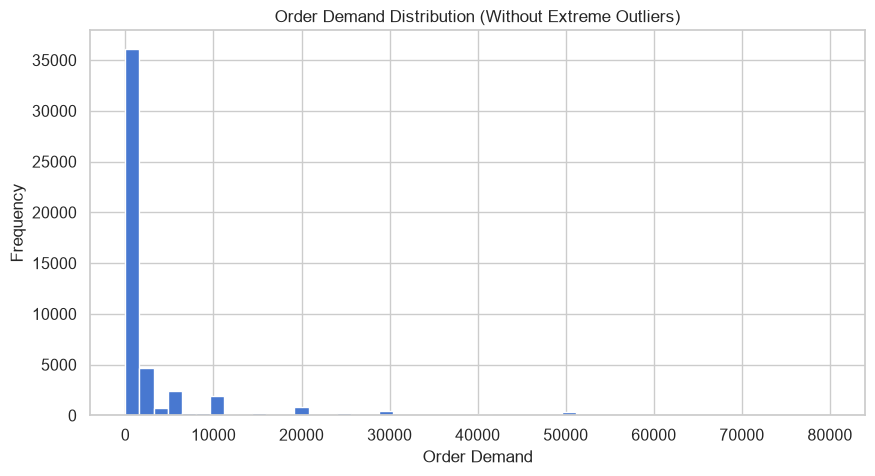

In [38]:
print("Dataset Shape:", df.shape)

# 1. Order Demand Distribution
plt.figure(figsize=(10, 5))

# Sample data for better performance and visualization
sample_data = df["Order_Demand"].sample(50000, random_state=42)

# Limit to 99th percentile to remove extreme outliers
upper_limit = sample_data.quantile(0.99)
sample_data = sample_data[sample_data <= upper_limit]

# Plot histogram
plt.hist(sample_data, bins=50)

# Titles and Labels
plt.title("Order Demand Distribution (Without Extreme Outliers)")
plt.xlabel("Order Demand")
plt.ylabel("Frequency")

plt.show()

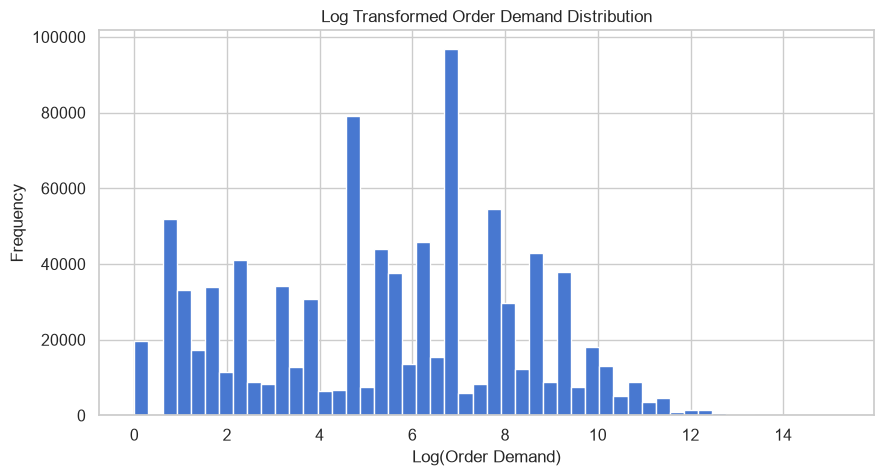

In [39]:
# 2. Log Transformation Plot

plt.figure(figsize=(10,5))
log_demand = np.log1p(df["Order_Demand"])
plt.hist(log_demand, bins=50)
plt.title("Log Transformed Order Demand Distribution")
plt.xlabel("Log(Order Demand)")
plt.ylabel("Frequency")
plt.show()

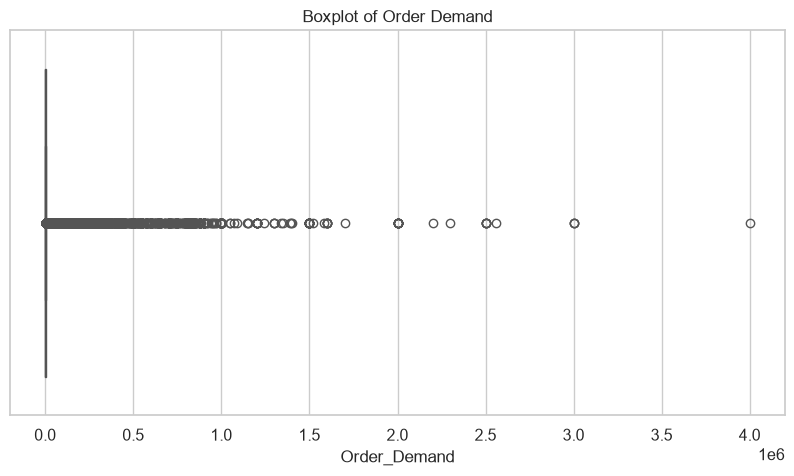

In [40]:
# 3. Boxplot for Outlier Detection

plt.figure(figsize=(10,5))
sns.boxplot(x=df["Order_Demand"])
plt.title("Boxplot of Order Demand")
plt.show()


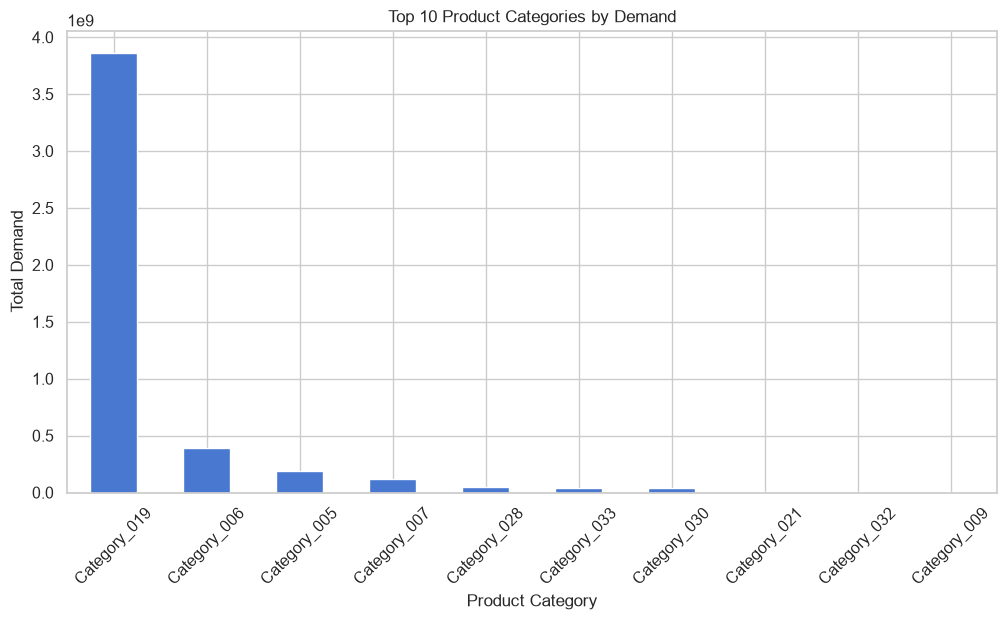

In [41]:
# 4. Product Category-wise Demand

category_demand = df.groupby("Product_Category")["Order_Demand"].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
category_demand.head(10).plot(kind="bar")
plt.title("Top 10 Product Categories by Demand")
plt.xlabel("Product Category")
plt.ylabel("Total Demand")
plt.xticks(rotation=45)
plt.show()

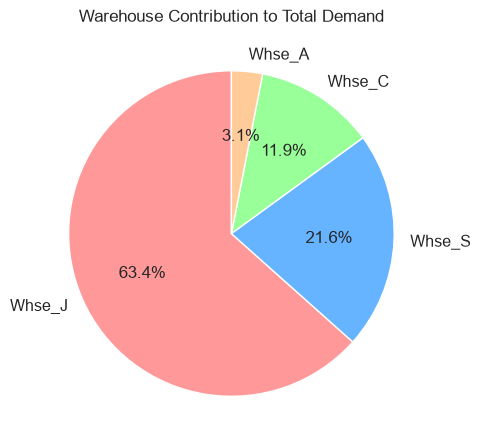

In [42]:
# 5. Pie Chart of Warehouse Share
warehouse_demand = df.groupby("Warehouse")["Order_Demand"].sum().sort_values(ascending=False)
plt.figure(figsize=(5,5))

warehouse_demand.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    colors=["#ff9999","#66b3ff","#99ff99","#ffcc99"]
)

plt.title("Warehouse Contribution to Total Demand")
plt.ylabel("")
plt.tight_layout()
plt.show()

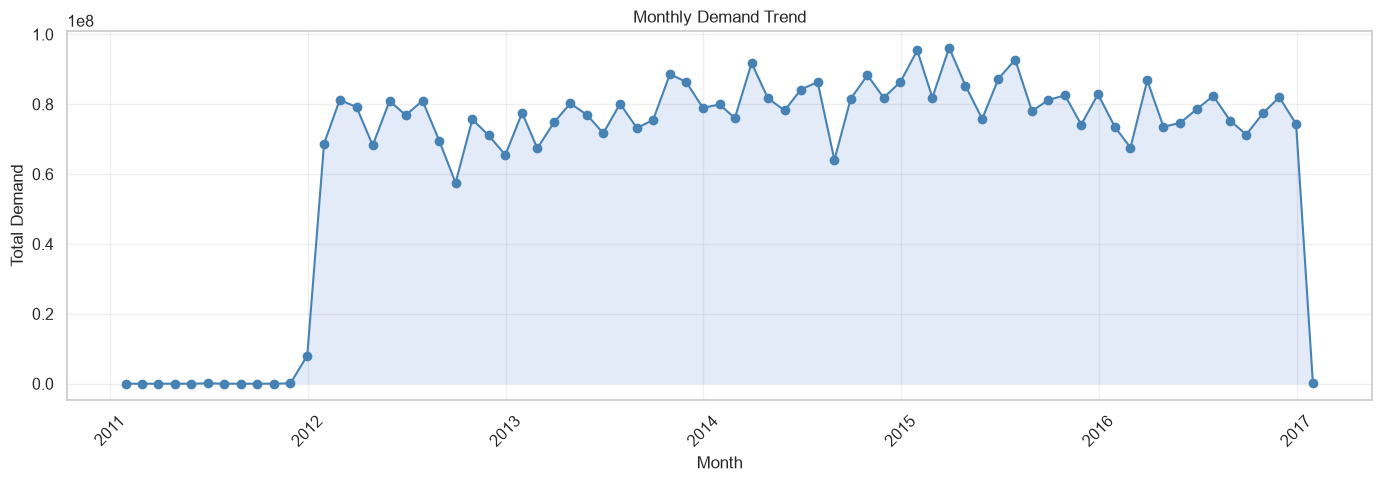

In [43]:
# 6. Monthly Demand Trend
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

monthly = df.resample("ME", on="Date")["Order_Demand"].sum()

plt.figure(figsize=(14,5))
plt.plot(monthly.index, monthly.values, marker="o", color="steelblue")
plt.fill_between(monthly.index, monthly.values, alpha=0.15)

plt.title("Monthly Demand Trend")
plt.xlabel("Month")
plt.ylabel("Total Demand")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

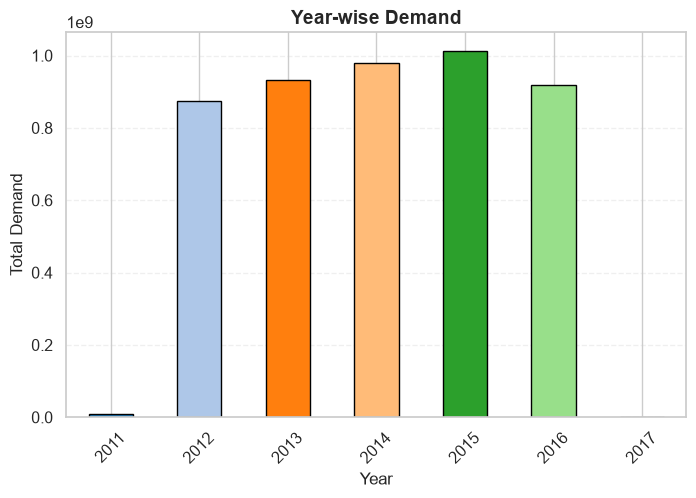

In [44]:
# 7. Year-wise Demand 

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Create Year column (FIX)
df["Year"] = df["Date"].dt.year

# Group by Year
yearly_demand = df.groupby("Year")["Order_Demand"].sum()

plt.figure(figsize=(8, 5))

# Distinct colors
colors = plt.cm.tab20(range(len(yearly_demand)))

yearly_demand.plot(
    kind="bar",
    color=colors,
    edgecolor="black"
)

plt.title("Year-wise Demand", fontsize=14, fontweight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Demand", fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()


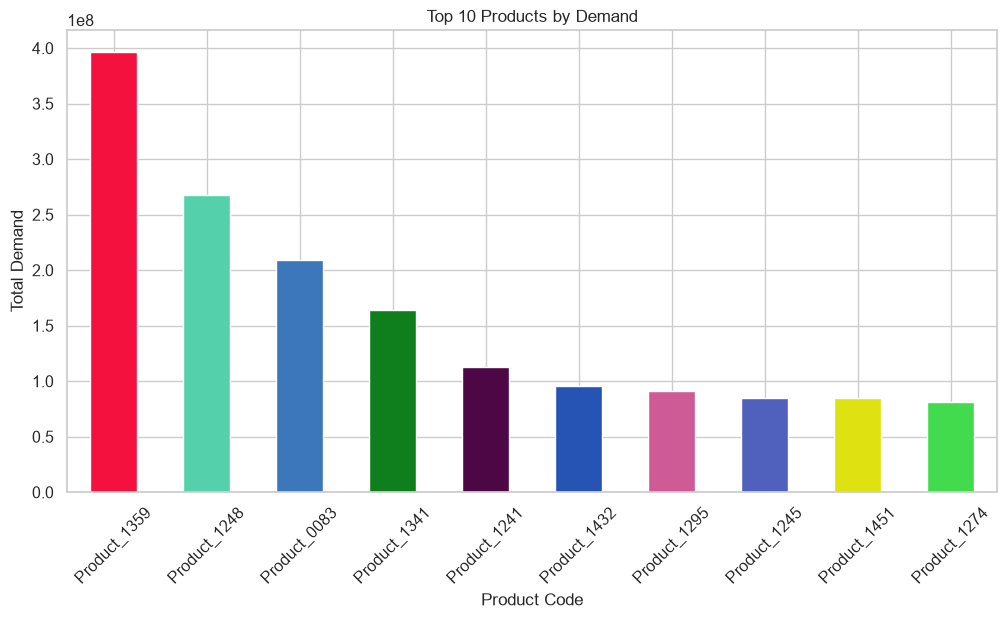

In [45]:
# 8. Top 10 Products by Demand

top_products = (
    df.groupby("Product_Code")["Order_Demand"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
colors = np.random.rand(len(top_products), 3)  

plt.figure(figsize=(12,6))
top_products.plot(kind="bar", color=colors)

plt.title("Top 10 Products by Demand")
plt.xlabel("Product Code")
plt.ylabel("Total Demand")
plt.xticks(rotation=45)
plt.show()


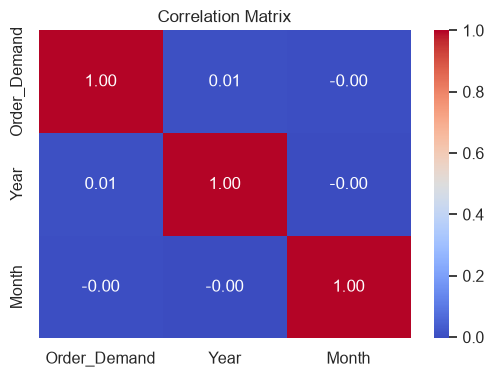

In [46]:
# 9. Correlation Matrix

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Create missing columns (FIX)
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

# Select numeric data safely
numeric_df = df[["Order_Demand", "Year", "Month"]]

plt.figure(figsize=(6,4))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix")
plt.show()


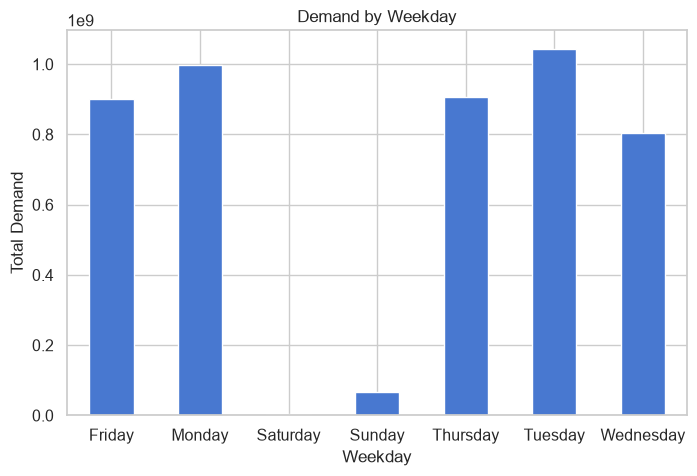

In [47]:
# 10. Demand by Weekday

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df["Weekday"] = df["Date"].dt.day_name()


weekday_demand = df.groupby("Weekday")["Order_Demand"].sum()

plt.figure(figsize=(8,5))
weekday_demand.plot(kind="bar")

plt.title("Demand by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Total Demand")

plt.xticks(rotation=0)
plt.show()

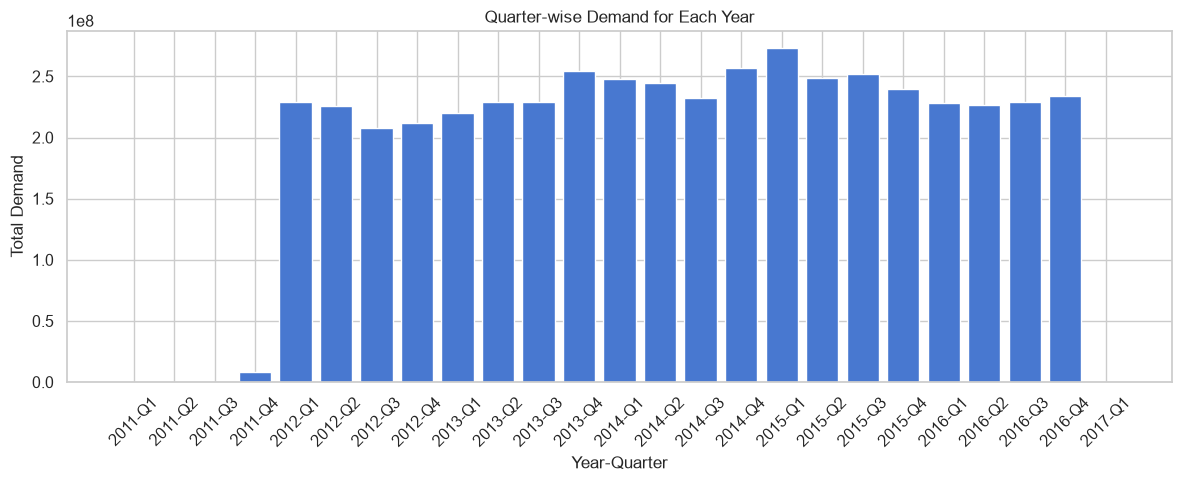

In [48]:
# 11. Quarter-wise Demand

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df["Year"] = df["Date"].dt.year
df["Quarter"] = "Q" + df["Date"].dt.quarter.astype(str)

quarter_year_demand = df.groupby(["Year", "Quarter"])["Order_Demand"].sum().reset_index()

# Create label for plotting
quarter_year_demand["Year_Quarter"] = quarter_year_demand["Year"].astype(str) + "-" + quarter_year_demand["Quarter"]

plt.figure(figsize=(12,5))
plt.bar(
    quarter_year_demand["Year_Quarter"],
    quarter_year_demand["Order_Demand"]
)

plt.title("Quarter-wise Demand for Each Year")
plt.xlabel("Year-Quarter")
plt.ylabel("Total Demand")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Step 6. Feature Engineering

In [49]:
df = df.sort_values("Date")

# Time-based features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Weekday"] = df["Date"].dt.weekday
df["Quarter"] = df["Date"].dt.quarter

# Cyclical encoding (IMPORTANT improvement)
df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)

df["Weekday_sin"] = np.sin(2 * np.pi * df["Weekday"] / 7)
df["Weekday_cos"] = np.cos(2 * np.pi * df["Weekday"] / 7)

# Lag features (CRITICAL for forecasting)
df["lag_1"] = df["Order_Demand"].shift(1)
df["lag_7"] = df["Order_Demand"].shift(7)
df["lag_30"] = df["Order_Demand"].shift(30)

# Rolling statistics
df["rolling_mean_7"] = df["Order_Demand"].rolling(7).mean()
df["rolling_std_7"] = df["Order_Demand"].rolling(7).std()

# Drop rows created by lagging
df = df.dropna().reset_index(drop=True)

Step 7. Encoding Categorical Features

In [50]:
for col in ["Product_Code", "Warehouse", "Product_Category"]:
    df[col] = df[col].astype("category").cat.codes

Step 8. Model Preparation

In [51]:
df = df.sort_values("Date")

split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

X_train = train.drop(columns=["Order_Demand", "Date"])
y_train = train["Order_Demand"]

X_test = test.drop(columns=["Order_Demand", "Date"])
y_test = test["Order_Demand"]

print(X_train.shape, X_test.shape)

(738228, 17) (184558, 17)


Step 9. Multiple Machine Learning Models

In [52]:
models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=12,
        min_samples_split=10,
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        min_samples_split=10,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
}

results = []

for name, model in models.items():
    # Train model
    model.fit(X_train, y_train)

    # Predictions
    predictions = model.predict(X_test)

    # Evaluation metrics
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    # Store results
    results.append([name, mae, rmse, r2])

# Final Results Table
results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2 Score"]
)

# Sort by best RMSE (lower is better)
results_df = results_df.sort_values("RMSE")

results_df

,Model,MAE,RMSE,R2 Score
2,Random Forest,3947.977449,17067.645738,0.716691
3,XGBoost,4525.183105,18270.435134,0.675354
1,Decision Tree,3995.958763,19600.549129,0.626363
0,Linear Regression,7565.840241,29203.002028,0.170593


Step 10. Best Model Selection

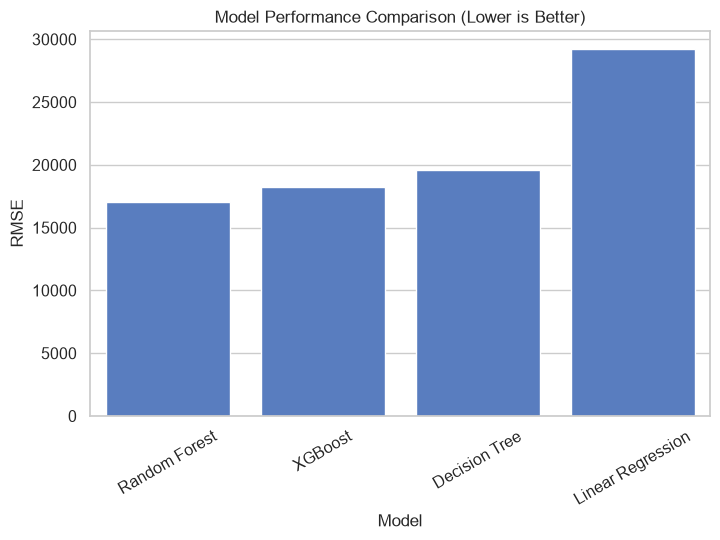

In [53]:
plt.figure(figsize=(8,5))
sns.barplot(data=results_df, x="Model", y="RMSE")
plt.title("Model Performance Comparison (Lower is Better)")
plt.xticks(rotation=30)
plt.show()

In [54]:
# Save Best Model Automatically

import joblib

# Get best model name from results table (lowest RMSE)
best_model_name = results_df.iloc[0]["Model"]

print("Best Model:", best_model_name)

# Get the already trained best model from models dictionary
best_model = models[best_model_name]

# Save the model
joblib.dump(best_model, "best_demand_forecasting_model.pkl")

print("Best model saved successfully as 'best_demand_forecasting_model.pkl'")

Best Model: Random Forest
Best model saved successfully as 'best_demand_forecasting_model.pkl'
